In [9]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.linear_model import LinearRegression

folder_path = r"D:\OneDrive\Trading\Market Making\data\runs\run_20260606_031617"

snapshots = pd.read_parquet(os.path.join(folder_path, "snapshots.parquet"))

snapshots

,ts,symbol,best_bid,best_ask,mid,microprice,best_bid_tick,best_ask_tick,mid_tick,spread,...,ask_delta,quote_churn,future_mid_100ms,future_return_100ms,future_mid_500ms,future_return_500ms,future_mid_1000ms,future_return_1000ms,future_mid_5000ms,future_return_5000ms
0,1780713725114,BTCUSDT,60980.06,60980.07,60980.065,60980.060338,6098006,6098007,6098006,0.01,...,0.0,0.0,60980.065,0.0,60980.065,0.0,60980.065,0.0,60964.005,-0.000263
1,1780713725214,BTCUSDT,60980.06,60980.07,60980.065,60980.060374,6098006,6098007,6098006,0.01,...,0.0,0.0,60980.065,0.0,60980.065,0.0,60980.065,0.0,60964.005,-0.000263
2,1780713725314,BTCUSDT,60980.06,60980.07,60980.065,60980.060372,6098006,6098007,6098006,0.01,...,0.0,0.0,60980.065,0.0,60980.065,0.0,60980.065,0.0,60964.005,-0.000263
3,1780713725414,BTCUSDT,60980.06,60980.07,60980.065,60980.060381,6098006,6098007,6098006,0.01,...,0.0,0.0,60980.065,0.0,60980.065,0.0,60980.065,0.0,60964.005,-0.000263
4,1780713725514,BTCUSDT,60980.06,60980.07,60980.065,60980.060381,6098006,6098007,6098006,0.01,...,0.0,0.0,60980.065,0.0,60980.065,0.0,60980.065,0.0,60964.005,-0.000263
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20512,1780715776314,BTCUSDT,60883.43,60883.44,60883.435,60883.431305,6088343,6088344,6088344,0.01,...,0.0,0.0,60883.435,0.0,NaN,NaN,NaN,NaN,NaN,NaN
20513,1780715776414,BTCUSDT,60883.43,60883.44,60883.435,60883.430575,6088343,6088344,6088344,0.01,...,0.0,0.0,60883.435,0.0,NaN,NaN,NaN,NaN,NaN,NaN
20514,1780715776514,BTCUSDT,60883.43,60883.44,60883.435,60883.430575,6088343,6088344,6088344,0.01,...,0.0,0.0,60883.435,0.0,NaN,NaN,NaN,NaN,NaN,NaN
20515,1780715776615,BTCUSDT,60883.43,60883.44,60883.435,60883.431305,6088343,6088344,6088344,0.01,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
"""
“Is microprice a statistically and economically meaningful estimator of future mid-price changes at horizon h?”

"""

df = snapshots

horizons = [100, 500, 1000, 5000]

df["micro_signal"] = (df["microprice"] - df["mid"]) / df["mid"] # expected return using microprice

for h in horizons:
    df[f"y_{h}ms"] = (df[f"future_mid_{h}ms"] - df["mid"]) / df["mid"] # future mid return

df = df.dropna()

In [11]:
"""
(A) Pearson IC (what you are using)

captures linear relationship
sensitive to outliers
tells you “how proportional is the move?”

"""

def ic(pred, y):
    return np.corrcoef(pred, y)[0,1]

"""
(B) Rank IC (Spearman IC)

ignores magnitude
only cares about ordering
much more realistic in microstructure

In HFT, Rank IC is often more meaningful than IC.

"""

def rank_ic(pred, y):
    return spearmanr(pred, y).statistic

results = {}
models = {}

for h in horizons:

    y = df[f"y_{h}ms"].values
    x = df["micro_signal"].values

    mask = np.isfinite(x) & np.isfinite(y) #filter out all nan values
    x = x[mask].reshape(-1, 1)
    y = y[mask]

    reg = LinearRegression()
    reg.fit(x, y)

    beta = reg.coef_[0]
    intercept = reg.intercept_

    pred = reg.predict(x)

    ic_val = np.corrcoef(x.flatten(), y)[0, 1]
    rank_ic_val = spearmanr(x.flatten(), y).statistic

    hit_rate = (np.sign(x.flatten()) == np.sign(y)).mean()

    pnl_proxy = np.mean(x.flatten() * y)
    pnl_std = np.std(x.flatten() * y)

    sharpe_proxy = pnl_proxy / (pnl_std + 1e-12)

    models[h] = {
        "model": reg,
        "beta": beta,
        "intercept": intercept,
        "ic": ic_val,
        "rank_ic": rank_ic_val
    }

    results[h] = {
        "Residual_IC": ic_val,
        "Residual_Rank_IC": rank_ic_val,
        "HitRate": hit_rate,
        "PnLProxy": pnl_proxy,
        "SharpeProxy": sharpe_proxy,
    }

microprice_residual_results_df = pd.DataFrame(results)
microprice_residual_results_df

,100,500,1000,5000
Residual_IC,1.685746e-01,1.573143e-01,1.484717e-01,1.159012e-01
Residual_Rank_IC,3.242009e-01,4.193615e-01,4.185877e-01,3.009603e-01
HitRate,6.517809e-02,1.946060e-01,2.966238e-01,5.399423e-01
PnLProxy,4.974009e-13,1.212229e-12,1.721302e-12,3.307260e-12
SharpeProxy,3.354492e-02,5.888562e-02,6.843412e-02,1.040224e-01


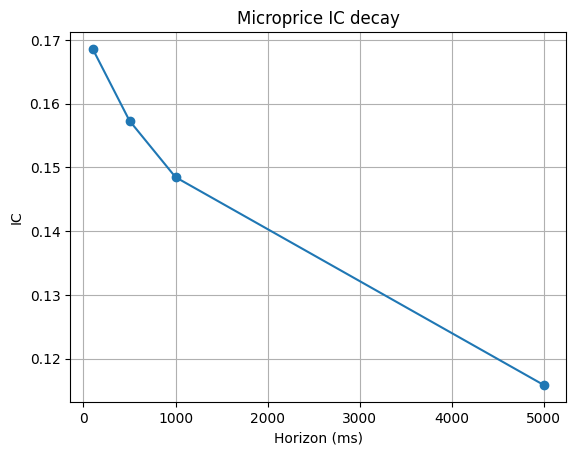

In [12]:
ic_curve = []

for h in horizons:
    y = df[f"y_{h}ms"].values
    x = df["micro_signal"].values

    mask = np.isfinite(x) & np.isfinite(y)

    ic_curve.append(ic(x[mask], y[mask]))

plt.plot(horizons, ic_curve, marker="o")
plt.title("Microprice IC decay")
plt.xlabel("Horizon (ms)")
plt.ylabel("IC")
plt.grid()
plt.show()

In [13]:
"""
So your model is approximately:

future_return_100ms
≈
5.519918083330967 x micro_signal

You can probably ignore the intercept.

"""

print("intercept:", models[100]["intercept"])
print("beta:", models[100]["beta"])
print("ic:", models[100]["ic"])

intercept: 1.793672958124054e-07
beta: 21.914535265581762
ic: 0.16857456581595126


In [14]:
artifact = {
    "model": "micro_signal",
    "target": "(microprice - mid / mid)",
    "horizon_ms": 100,
    "intercept": models[100]["intercept"],
    "beta": models[100]["beta"],
    "ic": models[100]["ic"]
}

joblib.dump(artifact, "data/micro_signal_model_3.pkl")

['data/micro_signal_model_3.pkl']